전체 데이터 형태: (10000, 67)
학습 데이터 X 형태: (8989, 10, 67)
학습 데이터 Y 형태: (8989, 64)
학습 시작...
Epoch 1/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0097 - val_loss: 0.0034
Epoch 2/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0057 - val_loss: 0.0033
Epoch 3/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0052 - val_loss: 0.0031
Epoch 4/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0049 - val_loss: 0.0031
Epoch 5/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0047 - val_loss: 0.0031
Epoch 6/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0046 - val_loss: 0.0030
Epoch 7/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0046 - val_loss: 0.0030
Epoch 8/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0045 - val_loss: 0.0030
Epoch 9/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0044 - val_loss: 0.0030
Epoch 10/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0043 - val_loss: 0.0029
Epoch 11/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - 

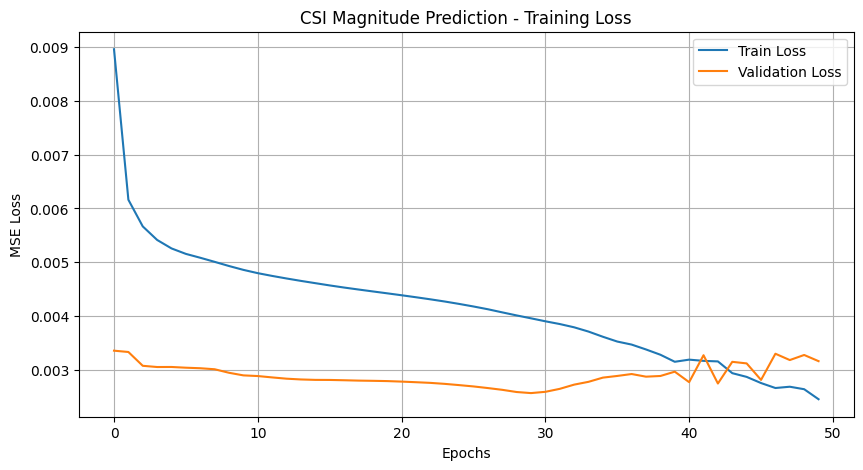

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


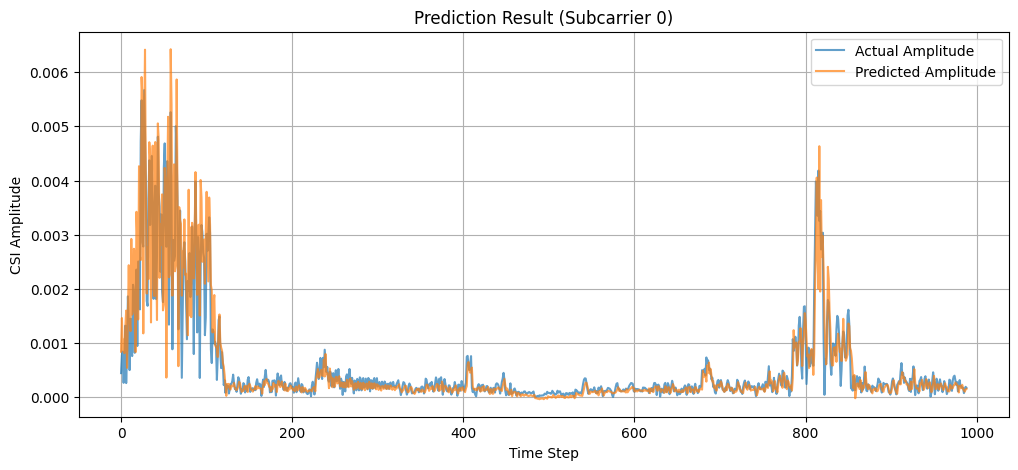

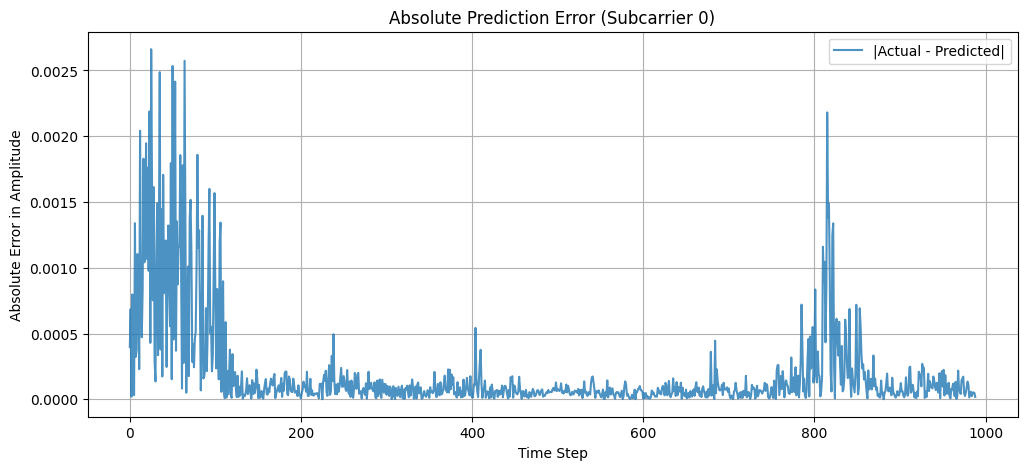

In [10]:
import scipy.io as sio
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input
import matplotlib.pyplot as plt
import os

# 셀 1: 데이터 로드, 진폭 변환 및 기본 학습 (Data Loading, Magnitude Conversion, and Basic Training)
# 이 셀에서는 데이터를 로드하고, 복소수 형태의 CSI 데이터를 진폭으로 변환한 후, 기본 LSTM 모델을 학습시킵니다.
# ==========================================
# 1) 데이터 로드
# ==========================================
mat_path = "csi_dataset.mat"  # 로컬 파일 경로

if not os.path.exists(mat_path):
    print(f"에러: 파일을 찾을 수 없습니다. 경로를 확인하세요: {mat_path}")
else:
    # 데이터 읽기
    data = sio.loadmat(mat_path)
    csi = data["csi"]        # (N, 64, 1, 1) complex
    rx_pos = data["rx_pos"]  # (N, 3)

    N, F, _, _ = csi.shape   # 전체 샘플 수(N, 약 10,000)와 서브캐리어 개수(F, 64)를 확인합니다.

    # ==========================================
    # 2) CSI -> 진폭(Magnitude) 변환
    # ==========================================
    csi = csi.reshape(N, F)  # (N, 64)
    
    # 복소수 CSI의 절댓값(진폭)
    csi_amp = np.abs(csi)    # (N, 64)

    # Feature 결합: [진폭(64), 위치(3)] = 67차원
    features = np.concatenate([csi_amp, rx_pos], axis=1)
    
    print(f"전체 데이터 형태: {features.shape}")  # (N, 67) 확인

    # 3) Train / Test 분할 (90% / 10%)
    split_percentage = 0.9
    split_point = round(N * split_percentage)

    train_feat = features[:split_point]
    test_feat = features[split_point:]

    # 4) 스케일링 (0~1 범위로 정규화)
    scaler = MinMaxScaler()
    scaler.fit(train_feat)

    scaled_train = scaler.transform(train_feat)
    scaled_test  = scaler.transform(test_feat)

    # 5) 시계열 윈도우 생성 함수
    def timeseries_preprocessing(scaled_train, scaled_test, lags):
        # 입력(X): 과거 lags개 시점의 [진폭+위치] (67차원)
        # 출력(Y): 다음 시점의 [진폭]만 (64차원)
        
        # Train
        X_tr, Y_tr = [], []
        for t in range(len(scaled_train) - lags - 1):
            X_tr.append(scaled_train[t : t+lags, :])
            Y_tr.append(scaled_train[t+lags, :64])  # 앞 64개(진폭)만 예측 타겟

        # Test
        X_te, Y_te = [], []
        for t in range(len(scaled_test) - lags - 1):
            X_te.append(scaled_test[t : t+lags, :])
            Y_te.append(scaled_test[t+lags, :64])

        return np.array(X_tr), np.array(Y_tr), np.array(X_te), np.array(Y_te)

    # 윈도우 크기 설정
    lags = 10
    
    # 데이터셋 생성
    X_train, Y_train, X_test, Y_test = timeseries_preprocessing(scaled_train, scaled_test, lags)

    print("학습 데이터 X 형태:", X_train.shape)  # (samples, 10, 67)
    print("학습 데이터 Y 형태:", Y_train.shape)  # (samples, 64)

    # 6) LSTM 모델 정의
    n_features = X_train.shape[2]  # 67
    output_dim = Y_train.shape[1]  # 64 (진폭 개수)

    model = Sequential()
    model.add(Input(shape=(lags, n_features)))   # (10, 67)
    model.add(LSTM(256))                         # LSTM 층
    model.add(Dense(output_dim))                 # 64개 진폭 예측

    model.compile(optimizer='adam', loss='mse')

    # 7) 학습 시작
    print("학습 시작...")
    history = model.fit(
        X_train, Y_train,
        epochs=50,
        validation_data=(X_test, Y_test),
        shuffle=False,
        verbose=1
    )

    # 8) 결과 그래프 (Train / Val Loss)
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('CSI Magnitude Prediction - Training Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 9) 예측 결과 시각화 (첫 번째 서브캐리어 실제 vs 예측)
    Y_pred_scaled = model.predict(X_test)

    # 진폭(앞 64차원)만 복원하기 위한 스케일러 정보
    scaler_amp_min   = scaler.min_[:64]
    scaler_amp_scale = scaler.scale_[:64]

    # inverse transform: X_orig = (X_scaled - min_) / scale_
    Y_true = (Y_test - scaler_amp_min) / scaler_amp_scale
    Y_pred = (Y_pred_scaled - scaler_amp_min) / scaler_amp_scale

    # 그래프 1: 서브캐리어 0 실제/예측 비교
    plt.figure(figsize=(12, 5))
    plt.plot(Y_true[:, 0], label='Actual Amplitude', alpha=0.7)
    plt.plot(Y_pred[:, 0], label='Predicted Amplitude', alpha=0.7)
    plt.title('Prediction Result (Subcarrier 0)')
    plt.xlabel('Time Step')
    plt.ylabel('CSI Amplitude')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 🔟 추가 그래프: 서브캐리어 0의 "절대 오차" 시퀀스
    error_sc0 = np.abs(Y_true[:, 0] - Y_pred[:, 0])

    plt.figure(figsize=(12, 5))
    plt.plot(error_sc0, label='|Actual - Predicted|', alpha=0.8)
    plt.title('Absolute Prediction Error (Subcarrier 0)')
    plt.xlabel('Time Step')
    plt.ylabel('Absolute Error in Amplitude')
    plt.legend()
    plt.grid(True)
    plt.show()


Experiment A: LSTM Units (Lag=10)
  Units= 32 -> Accuracy: 64.22%
  Units= 64 -> Accuracy: 64.35%
  Units=128 -> Accuracy: 63.75%
  Units=256 -> Accuracy: 63.67%
  Units=512 -> Accuracy: 64.35%

Experiment B: Lags (Units=256)
  Lag= 3 -> Accuracy: 62.72%
  Lag= 5 -> Accuracy: 62.21%
  Lag=10 -> Accuracy: 63.37%
  Lag=15 -> Accuracy: 63.89%
  Lag=20 -> Accuracy: 64.34%


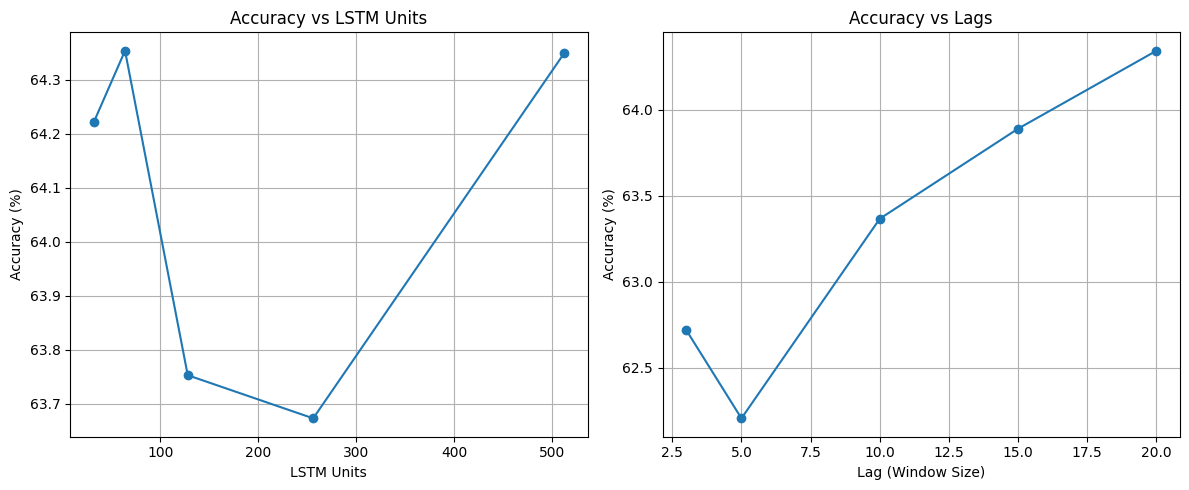

In [11]:
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

# -------------------------------------------------------
# 1. 진폭 부분만 inverse-scaling 하는 스케일러 만들기
# -------------------------------------------------------
def make_amp_scaler(scaler_all):
    """67차원(진폭64+위치3) scaler에서 앞 64개(진폭)만 떼서 복원용 scaler 생성"""
    scaler_amp = MinMaxScaler()
    scaler_amp.n_features_in_ = 64
    scaler_amp.feature_range  = scaler_all.feature_range
    
    scaler_amp.min_        = scaler_all.min_[:64].copy()
    scaler_amp.scale_      = scaler_all.scale_[:64].copy()
    scaler_amp.data_min_   = scaler_all.data_min_[:64].copy()
    scaler_amp.data_max_   = scaler_all.data_max_[:64].copy()
    scaler_amp.data_range_ = scaler_all.data_range_[:64].copy()
    return scaler_amp

# -------------------------------------------------------
# 2. Accuracy 계산 함수 (진폭 64개 기준)
# -------------------------------------------------------
def get_accuracy(model, X, Y, scaler_all):
    """
    model      : 학습된 LSTM
    X, Y       : (scaled 공간) 테스트 입력/정답
    scaler_all : 67차원 전체에 대해 fit된 MinMaxScaler
    반환       : accuracy (%) = (1 - MAE / mean(|Y_true|)) * 100
    """
    # 1) 모델 예측 (scaled)
    Y_pred_scaled = model.predict(X, verbose=0)
    
    # 2) 진폭(앞 64차원)만 inverse transform
    scaler_amp = make_amp_scaler(scaler_all)
    Y_true = scaler_amp.inverse_transform(Y)          # (N, 64)
    Y_pred = scaler_amp.inverse_transform(Y_pred_scaled)
    
    # 3) MAE 기반 accuracy
    mae = metrics.mean_absolute_error(Y_true, Y_pred)
    mean_val = np.mean(np.abs(Y_true)) + 1e-8   # 0 나눗셈 방지
    accuracy = (1.0 - mae / mean_val) * 100.0
    return accuracy

# -------------------------------------------------------
# 3. 주어진 units / lags로 모델 만들고 accuracy 리턴
# -------------------------------------------------------
def run_experiment(units, lags, scaled_train, scaled_test, scaler_all, epochs=15):
    """
    units : LSTM 유닛 수
    lags  : 시퀀스 길이
    """
    # 시계열 윈도우 생성
    X_train, Y_train, X_test, Y_test = timeseries_preprocessing(
        scaled_train, scaled_test, lags
    )
    
    n_features = X_train.shape[2]  # 67
    output_dim = Y_train.shape[1]  # 64
    
    # LSTM 모델 정의
    model = Sequential()
    model.add(Input(shape=(lags, n_features)))
    model.add(LSTM(units))
    model.add(Dense(output_dim))
    model.compile(optimizer='adam', loss='mse')
    
    # 학습
    model.fit(
        X_train, Y_train,
        epochs=epochs,
        batch_size=32,
        verbose=0,
        shuffle=False
    )
    
    # 정확도 계산
    acc = get_accuracy(model, X_test, Y_test, scaler_all)
    return acc

# =======================================================
# 실험 A: LSTM 유닛 수 변화에 따른 정확도
# =======================================================
units_list = [32, 64, 128, 256, 512]
fixed_lag = 10   # 윈도우 크기는 10으로 고정
acc_units = []

print(f"Experiment A: LSTM Units (Lag={fixed_lag})")
for u in units_list:
    acc = run_experiment(u, fixed_lag, scaled_train, scaled_test, scaler, epochs=15)
    acc_units.append(acc)
    print(f"  Units={u:3d} -> Accuracy: {acc:.2f}%")

# =======================================================
# 실험 B: 윈도우 크기(Lag) 변화에 따른 정확도
# =======================================================
lags_list = [3, 5, 10, 15, 20]
fixed_units = 256
acc_lags = []

print(f"\nExperiment B: Lags (Units={fixed_units})")
for l in lags_list:
    acc = run_experiment(fixed_units, l, scaled_train, scaled_test, scaler, epochs=15)
    acc_lags.append(acc)
    print(f"  Lag={l:2d} -> Accuracy: {acc:.2f}%")

# =======================================================
# 결과 시각화
# =======================================================
plt.figure(figsize=(12, 5))

# 그래프 1: Units vs Accuracy
plt.subplot(1, 2, 1)
plt.plot(units_list, acc_units, marker='o', linestyle='-')
plt.title('Accuracy vs LSTM Units')
plt.xlabel('LSTM Units')
plt.ylabel('Accuracy (%)')
plt.grid(True)

# 그래프 2: Lags vs Accuracy
plt.subplot(1, 2, 2)
plt.plot(lags_list, acc_lags, marker='o', linestyle='-')
plt.title('Accuracy vs Lags')
plt.xlabel('Lag (Window Size)')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.show()


Experiment A: LSTM Units (Lag=10)
  Units= 32 -> MAE-MAPE: 36.62%, RMSE-MAPE: 76.74%, R2: 0.801
  Units= 64 -> MAE-MAPE: 36.00%, RMSE-MAPE: 75.11%, R2: 0.810
  Units=128 -> MAE-MAPE: 36.57%, RMSE-MAPE: 74.93%, R2: 0.811
  Units=256 -> MAE-MAPE: 35.86%, RMSE-MAPE: 73.13%, R2: 0.820
  Units=512 -> MAE-MAPE: 35.97%, RMSE-MAPE: 73.47%, R2: 0.818

Experiment B: Lags (Units=256)
  Lag= 3 -> MAE-MAPE: 37.50%, RMSE-MAPE: 75.51%, R2: 0.806
  Lag= 5 -> MAE-MAPE: 37.73%, RMSE-MAPE: 75.57%, R2: 0.806
  Lag=10 -> MAE-MAPE: 36.66%, RMSE-MAPE: 74.44%, R2: 0.813
  Lag=15 -> MAE-MAPE: 35.96%, RMSE-MAPE: 74.15%, R2: 0.816
  Lag=20 -> MAE-MAPE: 35.73%, RMSE-MAPE: 73.09%, R2: 0.823


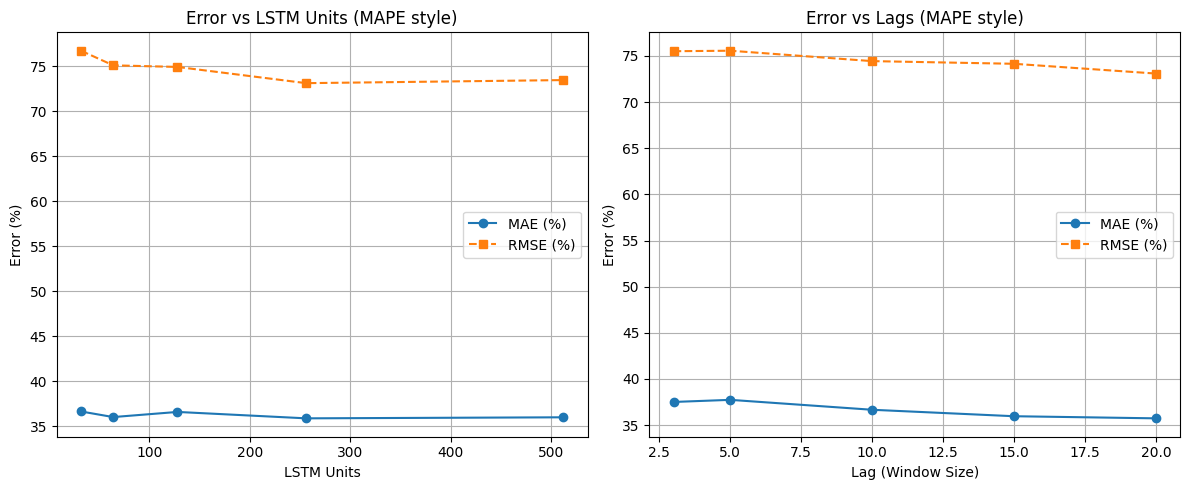

In [12]:
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

# -------------------------------------------------------
# 1. 진폭 부분만 inverse-scaling 하는 스케일러
# -------------------------------------------------------
def make_amp_scaler(scaler_all):
    """67차원(진폭64+위치3) scaler에서 앞 64개(진폭)만 떼서 복원용 scaler 생성"""
    scaler_amp = MinMaxScaler()
    scaler_amp.n_features_in_ = 64
    scaler_amp.feature_range  = scaler_all.feature_range

    scaler_amp.min_        = scaler_all.min_[:64].copy()
    scaler_amp.scale_      = scaler_all.scale_[:64].copy()
    scaler_amp.data_min_   = scaler_all.data_min_[:64].copy()
    scaler_amp.data_max_   = scaler_all.data_max_[:64].copy()
    scaler_amp.data_range_ = scaler_all.data_range_[:64].copy()
    return scaler_amp

# -------------------------------------------------------
# 2. 네가 준 공식대로 metric 계산
# -------------------------------------------------------
def compute_metrics(model, X, Y, scaler_all):
    """
    model  : 학습된 LSTM
    X, Y   : (scaled) 테스트 데이터
    scaler_all : 67차원 전체에 대해 fit된 MinMaxScaler
    return : dict 형태의 각종 지표
    """
    # 1) 예측 (scaled 공간)
    Y_pred_scaled = model.predict(X, verbose=0)

    # 2) 진폭(앞 64차원)만 inverse transform
    scaler_amp = make_amp_scaler(scaler_all)
    Y_true = scaler_amp.inverse_transform(Y)
    Y_pred = scaler_amp.inverse_transform(Y_pred_scaled)

    # 3) 기본 지표
    mae = metrics.mean_absolute_error(Y_true, Y_pred)
    mse = metrics.mean_squared_error(Y_true, Y_pred)
    rmse = np.sqrt(mse)
    r2 = metrics.r2_score(Y_true, Y_pred)

    # 4) 네가 준 비율 지표들
    data_range = np.max(Y_true) - np.min(Y_true) + 1e-8  # 0 방지
    mae_percent = 100 * mae / data_range
    rmse_percent = 100 * rmse / data_range

    mean_abs = np.mean(np.abs(Y_true)) + 1e-8
    mae_percent_mape_style = 100 * mae / mean_abs
    rmse_percent_mape_style = 100 * rmse / mean_abs

    return {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "r2": r2,
        "mae_percent": mae_percent,
        "rmse_percent": rmse_percent,
        "mae_percent_mape_style": mae_percent_mape_style,
        "rmse_percent_mape_style": rmse_percent_mape_style,
    }

# -------------------------------------------------------
# 3. units / lags에 따라 모델 학습 + metric 리턴
# -------------------------------------------------------
def run_experiment_metrics(units, lags, scaled_train, scaled_test, scaler_all, epochs=15):
    """
    units : LSTM 유닛 수
    lags  : 윈도우 길이
    """
    # 시계열 윈도우 생성
    X_train, Y_train, X_test, Y_test = timeseries_preprocessing(
        scaled_train, scaled_test, lags
    )

    n_features = X_train.shape[2]  # 67
    output_dim = Y_train.shape[1]  # 64

    # LSTM 모델 정의
    model = Sequential()
    model.add(Input(shape=(lags, n_features)))
    model.add(LSTM(units))
    model.add(Dense(output_dim))
    model.compile(optimizer='adam', loss='mse')

    # 학습
    model.fit(
        X_train, Y_train,
        epochs=epochs,
        batch_size=32,
        verbose=0,
        shuffle=False
    )

    # metric 계산
    metrics_dict = compute_metrics(model, X_test, Y_test, scaler_all)
    return metrics_dict

# =======================================================
# 실험 A: LSTM 유닛 수 변화에 따른 지표
# =======================================================
units_list = [32, 64, 128, 256, 512]
fixed_lag = 10
mae_mape_units = []
rmse_mape_units = []

print(f"Experiment A: LSTM Units (Lag={fixed_lag})")
for u in units_list:
    m = run_experiment_metrics(u, fixed_lag, scaled_train, scaled_test, scaler, epochs=15)
    mae_mape_units.append(m["mae_percent_mape_style"])
    rmse_mape_units.append(m["rmse_percent_mape_style"])
    print(f"  Units={u:3d} -> MAE-MAPE: {m['mae_percent_mape_style']:.2f}%, "
          f"RMSE-MAPE: {m['rmse_percent_mape_style']:.2f}%, R2: {m['r2']:.3f}")

# =======================================================
# 실험 B: 윈도우 크기(Lag) 변화에 따른 지표
# =======================================================
lags_list = [3, 5, 10, 15, 20]
fixed_units = 256
mae_mape_lags = []
rmse_mape_lags = []

print(f"\nExperiment B: Lags (Units={fixed_units})")
for l in lags_list:
    m = run_experiment_metrics(fixed_units, l, scaled_train, scaled_test, scaler, epochs=15)
    mae_mape_lags.append(m["mae_percent_mape_style"])
    rmse_mape_lags.append(m["rmse_percent_mape_style"])
    print(f"  Lag={l:2d} -> MAE-MAPE: {m['mae_percent_mape_style']:.2f}%, "
          f"RMSE-MAPE: {m['rmse_percent_mape_style']:.2f}%, R2: {m['r2']:.3f}")

# =======================================================
# 결과 시각화 (MAPE 스타일 MAE%, RMSE%)
# =======================================================
plt.figure(figsize=(12, 5))

# 그래프 1: Units vs 에러
plt.subplot(1, 2, 1)
plt.plot(units_list, mae_mape_units,  marker='o', linestyle='-', label='MAE (%)')
plt.plot(units_list, rmse_mape_units, marker='s', linestyle='--', label='RMSE (%)')
plt.title('Error vs LSTM Units (MAPE style)')
plt.xlabel('LSTM Units')
plt.ylabel('Error (%)')
plt.legend()
plt.grid(True)

# 그래프 2: Lags vs 에러
plt.subplot(1, 2, 2)
plt.plot(lags_list, mae_mape_lags,  marker='o', linestyle='-', label='MAE (%)')
plt.plot(lags_list, rmse_mape_lags, marker='s', linestyle='--', label='RMSE (%)')
plt.title('Error vs Lags (MAPE style)')
plt.xlabel('Lag (Window Size)')
plt.ylabel('Error (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
